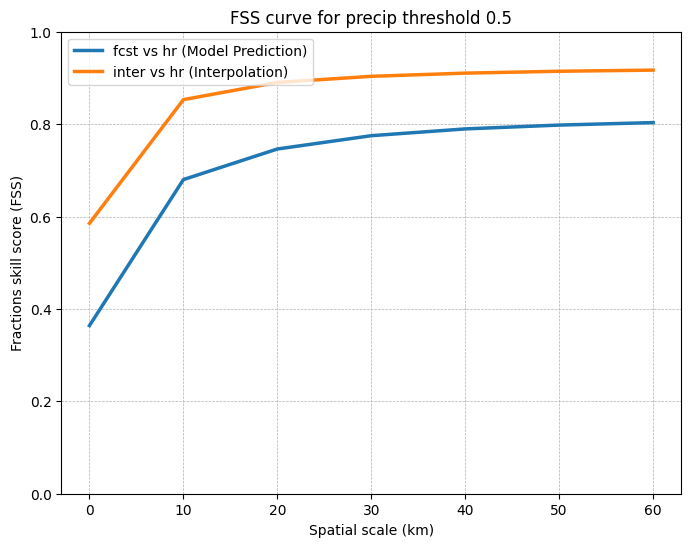

In [46]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_8_onestep_l1_nofc_aheadtop_005_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测
inter = ds['inter'].values  # 插值结果
hr = ds['hr'].values  # 观测数据

fcst = fcst.reshape(fcst.shape[1], -1)
inter = inter.reshape(inter.shape[1], -1)
hr = hr.reshape(hr.shape[1], -1)

# 固定阈值和尺度
threshold = 0.5
radii = [0, 10, 20, 30, 40, 50, 60]

# 计算FSS
fss_fcst = []
fss_inter = []

for radius in radii:
    # fcst vs hr
    fss_fcst.append(fss(fcst, hr, threshold, scale=radius))
    # inter vs hr
    fss_inter.append(fss(inter, hr, threshold, scale=radius))

# 绘图
plt.figure(figsize=(8, 6))

# 绘制加粗曲线
plt.plot(radii, fss_fcst, label='fcst vs hr (Model Prediction)', color='tab:blue', linewidth=2.5)
plt.plot(radii, fss_inter, label='inter vs hr (Interpolation)', color='tab:orange', linewidth=2.5)

plt.xlabel('Spatial scale (km)')
plt.ylabel('Fractions skill score (FSS)')
plt.title(f'FSS curve for precip threshold {threshold}')
plt.legend(loc='upper left')
plt.ylim(0, 1.0)  # 限制Y轴范围
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()


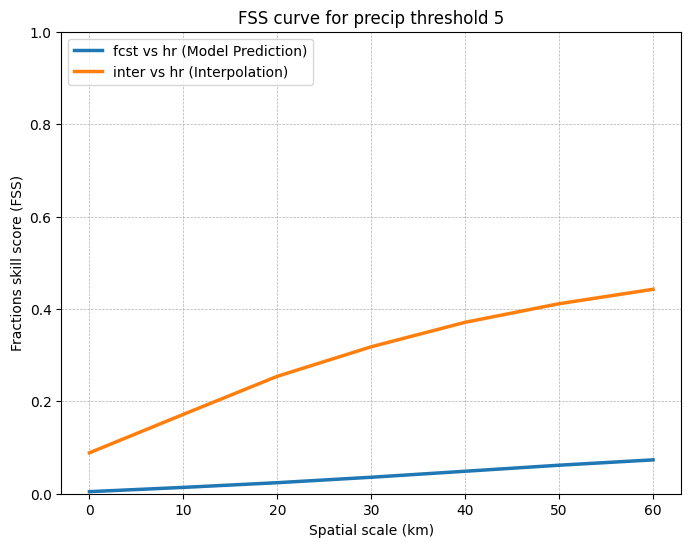

In [47]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_8_onestep_l1_nofc_aheadtop_005_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测
inter = ds['inter'].values  # 插值结果
hr = ds['hr'].values  # 观测数据

fcst = fcst.reshape(fcst.shape[1], -1)
inter = inter.reshape(inter.shape[1], -1)
hr = hr.reshape(hr.shape[1], -1)

# 固定阈值和尺度
threshold = 5
radii = [0, 10, 20, 30, 40, 50, 60]

# 计算FSS
fss_fcst = []
fss_inter = []

for radius in radii:
    # fcst vs hr
    fss_fcst.append(fss(fcst, hr, threshold, scale=radius))
    # inter vs hr
    fss_inter.append(fss(inter, hr, threshold, scale=radius))

# 绘图
plt.figure(figsize=(8, 6))

# 绘制加粗曲线
plt.plot(radii, fss_fcst, label='fcst vs hr (Model Prediction)', color='tab:blue', linewidth=2.5)
plt.plot(radii, fss_inter, label='inter vs hr (Interpolation)', color='tab:orange', linewidth=2.5)

plt.xlabel('Spatial scale (km)')
plt.ylabel('Fractions skill score (FSS)')
plt.title(f'FSS curve for precip threshold {threshold}')
plt.legend(loc='upper left')
plt.ylim(0, 1.0)  # 限制Y轴范围
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()


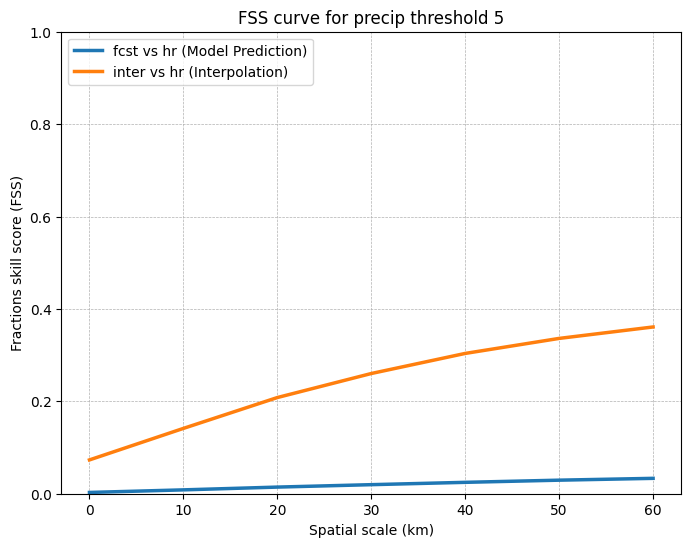

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_1_onestep_l1_nofc_aheadtop_0.5/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测
inter = ds['inter'].values  # 插值结果
hr = ds['hr'].values  # 观测数据

fcst = fcst.reshape(fcst.shape[1], -1)
inter = inter.reshape(inter.shape[1], -1)
hr = hr.reshape(hr.shape[1], -1)

# 固定阈值和尺度
threshold = 5
radii = [0, 10, 20, 30, 40, 50, 60]

# 计算FSS
fss_fcst = []
fss_inter = []

for radius in radii:
    # fcst vs hr
    fss_fcst.append(fss(fcst, hr, threshold, scale=radius))
    # inter vs hr
    fss_inter.append(fss(inter, hr, threshold, scale=radius))

# 绘图
plt.figure(figsize=(8, 6))

# 绘制加粗曲线
plt.plot(radii, fss_fcst, label='fcst vs hr (Model Prediction)', color='tab:blue', linewidth=2.5)
plt.plot(radii, fss_inter, label='inter vs hr (Interpolation)', color='tab:orange', linewidth=2.5)

plt.xlabel('Spatial scale (km)')
plt.ylabel('Fractions skill score (FSS)')
plt.title(f'FSS curve for precip threshold {threshold}')
plt.legend(loc='upper left')
plt.ylim(0, 1.0)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()


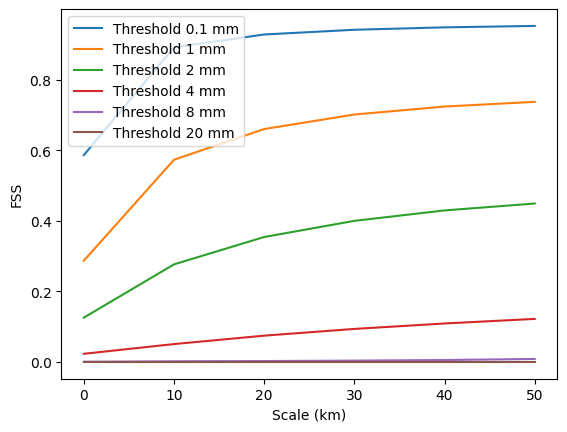

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_2_onestep_l1_nofc_aheadtop_5/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



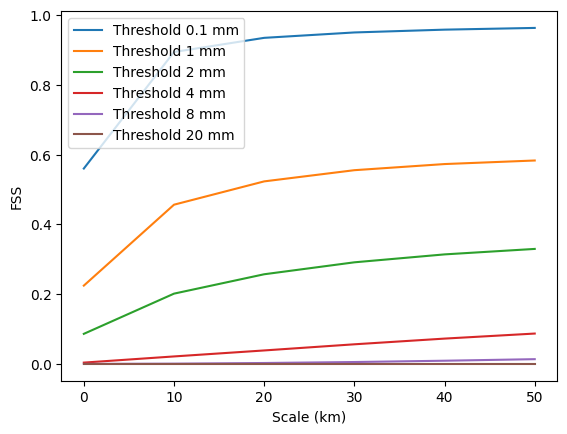

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_3_onestep_l1_nofc_aheadtop_50/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



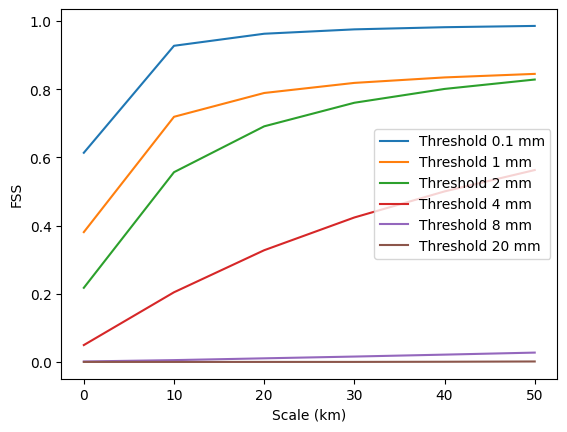

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex17_onestepwgan_weightmae_aheadtop_0.008/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

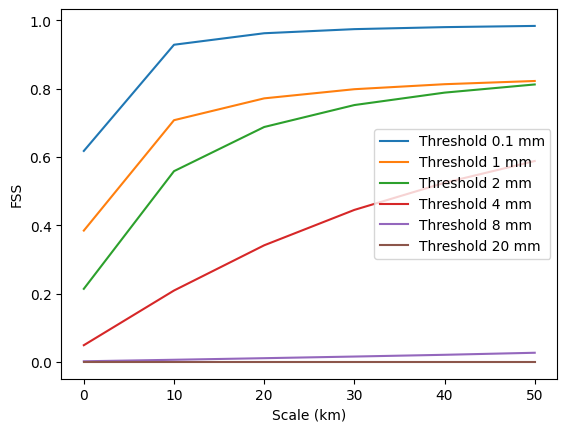

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

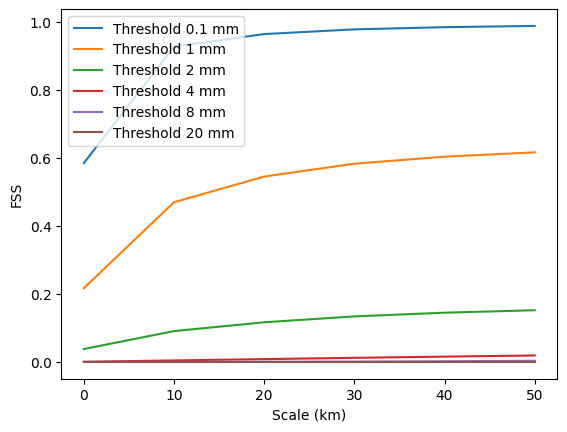

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_4_onestepwgan_cri5_181_025_l1_aheadtop_40_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()#######为什么这么多一样的呀

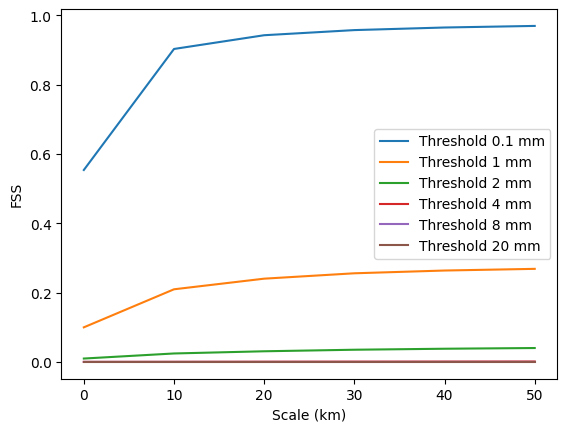

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_5_onestepwgan_cri5_1500_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

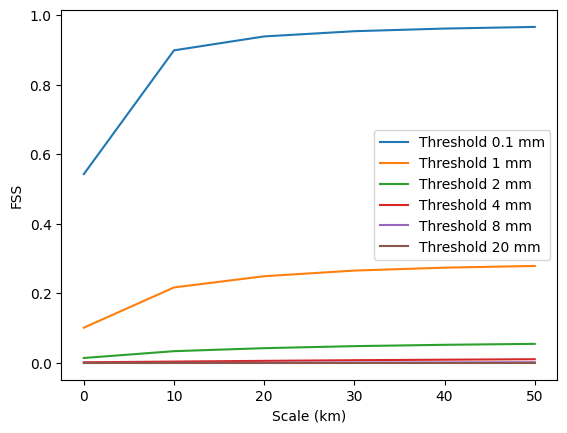

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

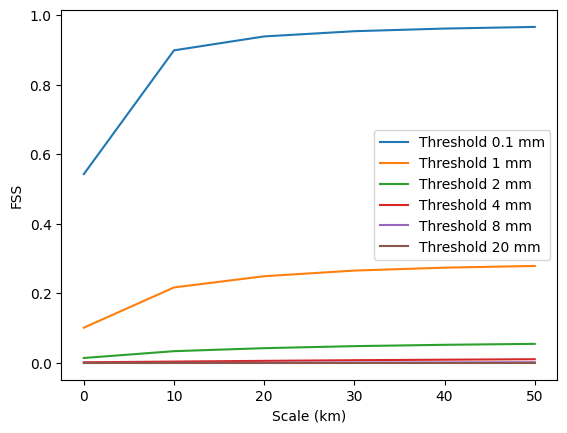

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

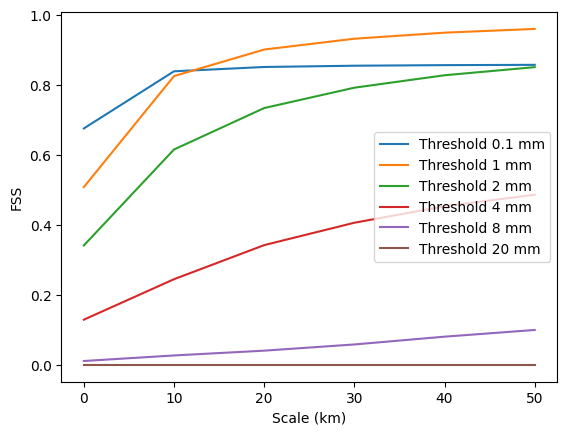

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



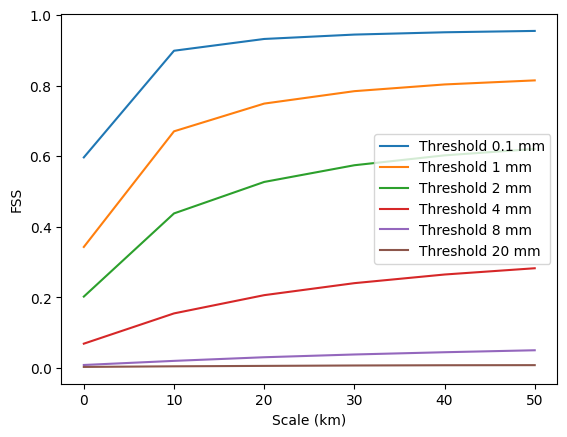

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

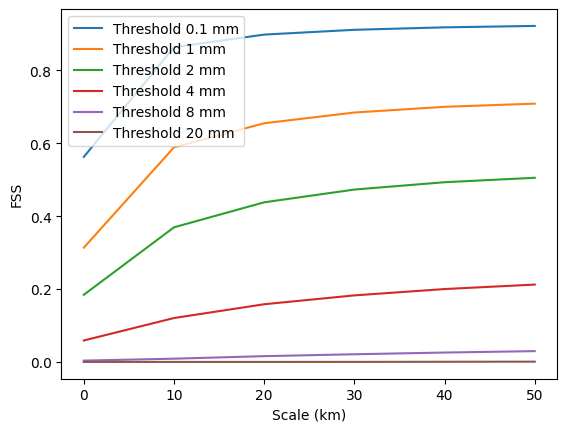

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



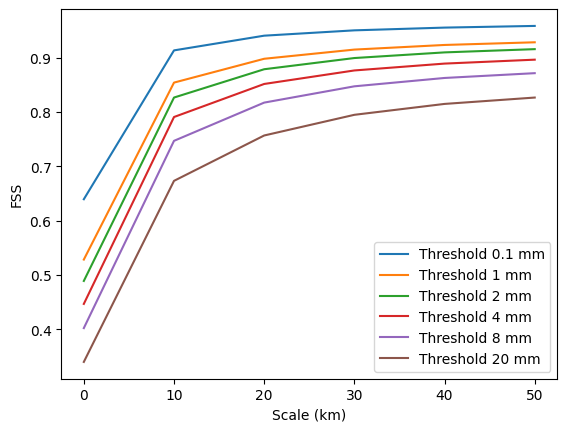

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_7_onestep_l1_nofc_aheadtop_05_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()